peaks = [  898  2693  4489  6284  8080  9875 11671 13467 15262 17058 18853 20649
 22444 24240 26035 27831 29626 31422 33217 35013 36809 38604 40400 42195
 43991 45786 47582 49377 51173 52968 54764 56559 58355 60150 61946 63742
 65537 67333 69128 70924 72719 74515 76310 78106 79901 81697 83492 85288
 87084 88879 90675 92470 94266 96061 97857 99652]
np.abs(y[peaks[i]] - H_ust) = 0.04565161656395378, y[peaks[i]] = 1.0459878769933628, H_ust = 1.000336260429409, [peaks[i]] = [43991], i = 24
Время перехода t_p = 1539.70039700397
H_ust = 1.000336260429409
H_max = 1.9390892545910587
Упражнение 1
Время нарастания: 15.89 сек
Перерегулирование: 93.84%
Частота колебаний: 0.10 рад/с
Время достижения первого максимума: 31.43 сек
Декремент затухания: 0.94
t max: 31.430314303143028
t min: 62.860628606286056


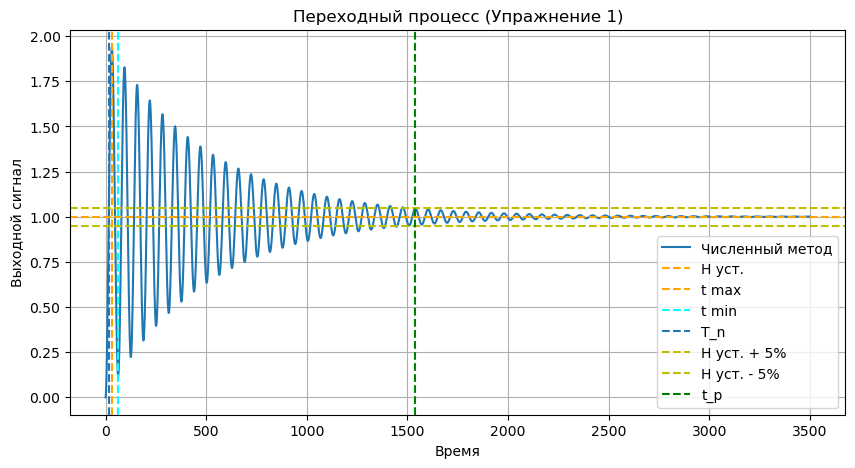

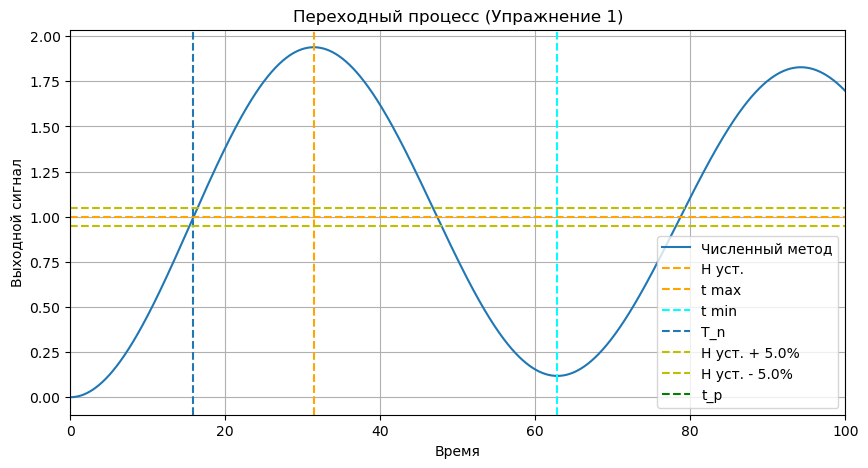

In [34]:
# Упражнение 1: Прямые показатели качества для колебательного звена
T = 10
xi = 0.02
K = 1

# Передаточная функция
num1 = [K]
den1 = [T**2, 2*xi*T, 1]

system1 = signal.TransferFunction(num1, den1)

t, y = signal.step(system1, N=100000)


# Аналитический и численный метод (переходная характеристика)

# Вычисление показателей качества

H_ust = y[-1]  # Установившееся значение
# H_ust = K


# Время перехода
delta = 0.05

peaks, _ = signal.find_peaks(y)

t_p = 0

print(f"peaks = {peaks}")

for i in range(len(peaks)):
    if(np.abs(y[peaks[i]] - H_ust) < (delta * H_ust)):
        t_p = t[peaks[i]]
        print(f"np.abs(y[peaks[i]] - H_ust) = {np.abs(y[peaks[i]] - H_ust)}, y[peaks[i]] = {y[peaks[i]]}, H_ust = {H_ust}, [peaks[i]] = {[peaks[i]]}, i = {i}")
        break
print(f"Время перехода t_p = {t_p}")
        
# Время нарастания
crossings = np.where(np.diff(np.sign(y - H_ust)))[0]  # Поиск пересечений с установившимся значением
T_n = t[crossings[0]] if len(crossings) > 0 else np.nan  

# Определение H_min и H_max после T_n
y_after_Tn = y[t >= T_n]
H_max = max(y_after_Tn) if len(y_after_Tn) > 0 else np.nan
for i in range(len(y)):
    if(y[i] == H_max):
        T_max = t[i]
        break
        
H_min = min(y_after_Tn) if len(y_after_Tn) > 0 else np.nan
for i in range(len(y)):
    if(y[i] == H_min):
        T_min = t[i]
        break
        
sigma = (H_max - H_ust) / H_ust * 100  # Перерегулирование

# T_max = t[np.argmax(y_after_Tn)] if len(y_after_Tn) > 0 else np.nan  # Время первого максимума

T_osc = 2 * np.abs(T_max - T_min)
omega = 2 * np.pi / T_osc if T_osc > 0 else np.nan

# n_osc = len(crossings) // 2  # Число колебаний
kappa = (H_ust - H_min) / (H_max - H_ust) if H_max != H_ust else np.nan  # Декремент затухания

print(f"H_ust = {H_ust}")
print(f"H_max = {H_max}")

# Вывод результатов
print(f"Упражнение 1")
print(f"Время нарастания: {T_n:.2f} сек")
print(f"Перерегулирование: {sigma:.2f}%")
print(f"Частота колебаний: {omega:.2f} рад/с")
# print(f"Число колебаний: {n_osc}")
print(f"Время достижения первого максимума: {T_max:.2f} сек")
print(f"Декремент затухания: {kappa:.2f}")
print(f"t max: {T_max}")
print(f"t min: {T_min}")

plt.figure(figsize=(10, 5))
plt.plot(t, y, label="Численный метод")
plt.axhline(H_ust, color='orange', linestyle='--', label='H уст.')
plt.axvline(T_max, color='orange', linestyle='--', label='t max')
plt.axvline(T_min, color='cyan', linestyle='--', label='t min')
plt.axvline(T_n, linestyle='--', label='T_n')
plt.axhline(H_ust + delta * H_ust, color='y', linestyle='--', label='H уст. + 5%')
plt.axhline(H_ust - delta * H_ust, color='y', linestyle='--', label='H уст. - 5%')
plt.axvline(t_p, color='green', linestyle='--', label='t_p')
plt.title("Переходный процесс (Упражнение 1)")
plt.xlabel("Время")
plt.ylabel("Выходной сигнал")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(t, y, label="Численный метод")
plt.axhline(H_ust, color='orange', linestyle='--', label='H уст.')
plt.axvline(T_max, color='orange', linestyle='--', label='t max')
plt.axvline(T_min, color='cyan', linestyle='--', label='t min')
plt.axvline(T_n, linestyle='--', label='T_n')
plt.axhline(H_ust + delta * H_ust, color='y', linestyle='--', label=f'H уст. + {delta*100}%')
plt.axhline(H_ust - delta * H_ust, color='y', linestyle='--', label=f'H уст. - {delta*100}%')
plt.axvline(t_p, color='green', linestyle='--', label='t_p')
plt.title("Переходный процесс (Упражнение 1)")
plt.xlabel("Время")
plt.ylabel("Выходной сигнал")
plt.legend()
plt.grid()
plt.xlim(0, 100)
plt.show()

Колебательность (μ): 4.8990
Степень устойчивости (η): 0.2000
M = 25.416954149343585, L max = 28.10247010973468
Полюса системы: [-0.2+0.9797959j -0.2-0.9797959j]


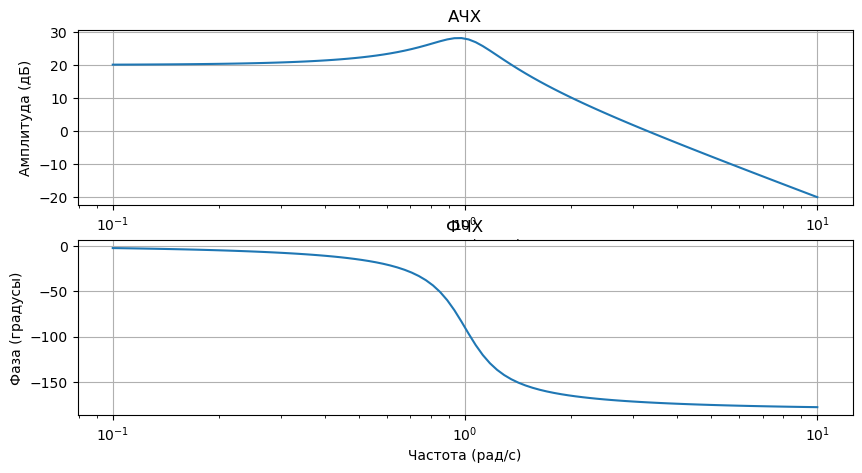

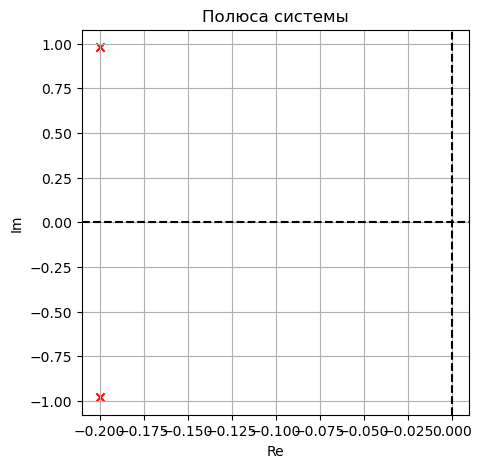

In [29]:
# Упражнение 2: Косвенные показатели качества
T = 1
xi = 0.2
K = 10

num2 = [K]
den2 = [T**2, 2*xi*T, 1]
system2 = signal.TransferFunction(num2, den2)

# Вычисление запасов устойчивости
w, mag, phase = signal.bode(system2)

# Нахождение корней характеристического уравнения
poles = np.roots(den2)

# Колебательность и степень устойчивости
mu = np.max(np.abs(poles.imag / poles.real))  # max |Im(s) / Re(s)|
eta = np.min(np.abs(poles.real))  # min |Re(s)|

# Максимальное значение L(w) в дБ
L_max = np.max(mag)

# Вычисление M
M = 10**(L_max / 20)

print(f"Колебательность (μ): {mu:.4f}")
print(f"Степень устойчивости (η): {eta:.4f}")

print(f'M = {M}, L max = {L_max}')

print(f"Полюса системы: {poles}")

plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.semilogx(w, mag)
plt.title("АЧХ")
plt.xlabel("Частота (рад/с)")
plt.ylabel("Амплитуда (дБ)")
plt.grid()

plt.subplot(2, 1, 2)
plt.semilogx(w, phase)
plt.title("ФЧХ")
plt.xlabel("Частота (рад/с)")
plt.ylabel("Фаза (градусы)")
plt.grid()
plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(poles.real, poles.imag, marker='x', color='r')
plt.axhline(0, color='k', linestyle='--')
plt.axvline(0, color='k', linestyle='--')
plt.title("Полюса системы")
plt.xlabel("Re")
plt.ylabel("Im")
plt.grid()
plt.show()



y[-1] = 1.0000000000000009
peaks = [ 25  60  97 133 169 205 242 278 314]
np.abs(y[peaks[i]] - H_ust) = 0.08117035443032083, y[peaks[i]] = 1.0811703544303208, H_ust = 1.0, [peaks[i]] = [25], i = 0
Время перехода t_p = 12.012012012012013
H_ust = 1.0
H_max = 1.0811703544303208
H_min = 0.968815621870969
Время нарастания: 3.60 сек
Перерегулирование: 8.12%
Частота колебаний: 2.24 рад/с
Время достижения первого максимума: 5.01 сек
Декремент затухания: 0.38
t max: 5.005005005005005
t min: 3.6036036036036037


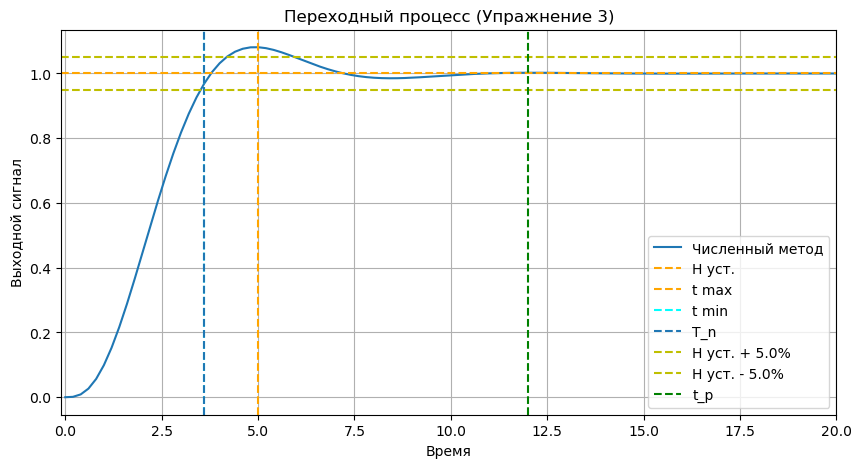

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Упражнение 3: Прямые показатели качества для сложной САУ
K = 1
T1 = 1
T2 = 1
xi = 0.50

num3 = [K]
den3 = [T1*T2**2, 2*xi*T1*T2 + T2**2, T1 + 2*xi*T2, 1]
system3 = signal.TransferFunction(num3, den3)

# Построение переходного процесса
t, y = signal.step(system3, T=np.linspace(0, 200, 1000))
print(f'y[-1] = {y[-1]}')
H_ust = np.round(y[-1], 2)  # Установившееся значение
# H_ust = K


# Время перехода
delta = 0.05

peaks, _ = signal.find_peaks(y)

print(f"peaks = {peaks}")

t_p = np.nan

for i in range(len(peaks)):
    if(np.abs(y[peaks[i]] - H_ust) < (delta * H_ust)):
        t_p = t[peaks[i]]
        break
    print(f"np.abs(y[peaks[i]] - H_ust) = {np.abs(y[peaks[i]] - H_ust)}, y[peaks[i]] = {y[peaks[i]]}, H_ust = {H_ust}, [peaks[i]] = {[peaks[i]]}, i = {i}")
    
print(f"Время перехода t_p = {t_p}")
        
# Время нарастания
crossings = np.where(np.diff(np.sign(y - H_ust)))[0]  # Поиск пересечений с установившимся значением
T_n = t[crossings[0]] if len(crossings) > 0 else 0

# Определение H_min и H_max после T_n
y_after_Tn = y[t >= T_n]
H_max = max(y)
# H_max = max(y_after_Tn) if len(y_after_Tn) > 0 else np.nan
for i in range(len(y)):
    if(y[i] == H_max):
        T_max = t[i]
        break
        
H_min = min(y_after_Tn) if len(y_after_Tn) > 0 else np.nan
for i in range(len(y)):
    if(y[i] == H_min):
        T_min = t[i]
        break
        
sigma = (H_max - y[-1]) / y[-1] * 100  # Перерегулирование

# T_max = t[np.argmax(y_after_Tn)] if len(y_after_Tn) > 0 else np.nan  # Время первого максимума


T_osc = 2 * np.abs(T_max - T_min)
omega = 2 * np.pi / T_osc if T_osc > 0 else np.nan

# n_osc = len(crossings) // 2  # Число колебаний
kappa = (y[-1] - H_min) / (H_max - y[-1]) if H_max != y[-1] else np.nan  # Декремент затухания

print(f"H_ust = {H_ust}")
print(f"H_max = {H_max}")
print(f"H_min = {H_min}")

# Вывод результатов
print(f"Время нарастания: {T_n:.2f} сек")
print(f"Перерегулирование: {sigma:.2f}%")
print(f"Частота колебаний: {omega:.2f} рад/с")
# print(f"Число колебаний: {n_osc}")
print(f"Время достижения первого максимума: {T_max:.2f} сек")
print(f"Декремент затухания: {kappa:.2f}")
print(f"t max: {T_max}")
print(f"t min: {T_min}")


plt.figure(figsize=(10, 5))
plt.plot(t, y, label="Численный метод")
plt.axhline(H_ust, color='orange', linestyle='--', label='H уст.')
plt.axvline(T_max, color='orange', linestyle='--', label='t max')
plt.axvline(T_min, color='cyan', linestyle='--', label='t min')
plt.axvline(T_n, linestyle='--', label='T_n')
plt.axhline(H_ust + delta * H_ust, color='y', linestyle='--', label=f'H уст. + {delta*100}%')
plt.axhline(H_ust - delta * H_ust, color='y', linestyle='--', label=f'H уст. - {delta*100}%')
plt.axvline(t_p, color='green', linestyle='--', label='t_p')
plt.title("Переходный процесс (Упражнение 3)")
plt.xlabel("Время")
plt.ylabel("Выходной сигнал")
plt.legend()
plt.grid()
plt.xlim(-0.1, 20)
plt.show()
